#  ToxiTube — YouTube Comment Toxicity Detector
##Modèles classiques

**Objectif de ce notebook :**
- Entraîner 3 modèles classiques (LR + TF-IDF, LR + FastText, SVM + TF-IDF)
- Évaluer avec F1-macro, Recall, Precision
- Produire le tableau comparatif + visualisations
- Analyser les mots les plus discriminants

### Chargement des checkpoints

**Pourquoi recharger ?**
Ce notebook est indépendant de `02_preprocessing.ipynb`.
On recharge toutes les matrices et objets sauvegardés précédemment
pour ne pas recalculer le preprocessing (~5 min) à chaque fois.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
os.makedirs('../figures', exist_ok=True)

# Chargement du df preprocessé
df = pd.read_csv('../data/checkpoints/df_preprocessed.csv')

# Chargement du vectoriseur TF-IDF
tfidf = joblib.load('../data/checkpoints/tfidf.joblib')

# Chargement des splits et embeddings
splits = joblib.load('../data/checkpoints/splits.joblib')
X_train_raw   = splits['X_train_raw']
X_test_raw    = splits['X_test_raw']
y_train       = splits['y_train']
y_test        = splits['y_test']
X_train_tfidf = splits['X_train_tfidf']
X_test_tfidf  = splits['X_test_tfidf']
X_train_ft    = splits['X_train_ft']
X_test_ft     = splits['X_test_ft']

print(f' Tout chargé')
print(f'   df          : {df.shape}')
print(f'   Train       : {len(y_train):,} exemples')
print(f'   Test        : {len(y_test):,} exemples')
print(f'   TF-IDF      : {X_train_tfidf.shape}')
print(f'   FastText    : {X_train_ft.shape}')

 Tout chargé
   df          : (159571, 13)
   Train       : 127,656 exemples
   Test        : 31,915 exemples
   TF-IDF      : (127656, 50000)
   FastText    : (127656, 300)


### Partie E — Modèles classiques

**Pourquoi commencer par des modèles classiques ?**
Avant d'utiliser BERT (lourd et complexe), on établit une **baseline solide**
avec des modèles rapides et interprétables.

**Les 3 modèles :**
1. **Logistic Regression + TF-IDF** → baseline rapide, très interprétable
2. **Logistic Regression + FastText** → compare embeddings sémantiques vs fréquences
3. **LinearSVC + TF-IDF** → souvent le meilleur modèle classique sur texte

**Métrique principale : F1-macro**
Avec 90% de commentaires normaux, l'accuracy est trompeuse.
Un modèle qui prédit "normal" tout le temps → 90% accuracy, mais inutile.
Le F1-macro traite les deux classes de façon équilibrée.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    accuracy_score, confusion_matrix, classification_report
)

def evaluate_model(model, X_test, y_test, model_name='Modèle'):
    """
    Évalue un modèle et retourne un dictionnaire de métriques.
    """
    y_pred = model.predict(X_test)
    metrics = {
        'Modèle'           : model_name,
        'Accuracy'         : accuracy_score(y_test, y_pred),
        'F1-macro'         : f1_score(y_test, y_pred, average='macro'),
        'F1-toxique'       : f1_score(y_test, y_pred, pos_label=1, average='binary'),
        'Recall-toxique'   : recall_score(y_test, y_pred, pos_label=1),
        'Precision-toxique': precision_score(y_test, y_pred, pos_label=1),
    }
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    for k, v in metrics.items():
        if k != 'Modèle':
            print(f'  {k:<22} : {v:.4f}')
    return metrics, y_pred

print(' Fonction evaluate_model() définie')

 Fonction evaluate_model() définie


**Modèle 1 — Logistic Regression + TF-IDF**

C'est notre baseline de référence. Simple, rapide, et souvent très compétitif en NLP.

`class_weight='balanced'` est crucial ici : il compense automatiquement
le déséquilibre 90/10 en donnant plus de poids aux commentaires toxiques.
Sans ça, le modèle ignorerait la classe minoritaire.

In [3]:
print('Entraînement Logistic Regression + TF-IDF...')

lr_tfidf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_tfidf.fit(X_train_tfidf, y_train)

metrics_lr_tfidf, y_pred_lr_tfidf = evaluate_model(
    lr_tfidf, X_test_tfidf, y_test,
    model_name='Logistic Regression + TF-IDF'
)
print('\n Modèle 1 terminé')

Entraînement Logistic Regression + TF-IDF...

  Logistic Regression + TF-IDF
  Accuracy               : 0.9406
  F1-macro               : 0.8568
  F1-toxique             : 0.7474
  Recall-toxique         : 0.8647
  Precision-toxique      : 0.6581

 Modèle 1 terminé


**Modèle 2 — Logistic Regression + FastText**

On remplace TF-IDF par les embeddings FastText.

La différence fondamentale : FastText capture le **sens** des mots.
Exemple : `idiot` et `moron` ont des scores TF-IDF indépendants,
mais leurs vecteurs FastText sont proches → le modèle généralise mieux.

In [4]:
print('Entraînement Logistic Regression + FastText...')

lr_ft = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_ft.fit(X_train_ft, y_train)

metrics_lr_ft, y_pred_lr_ft = evaluate_model(
    lr_ft, X_test_ft, y_test,
    model_name='Logistic Regression + FastText'
)
print('\n Modèle 2 terminé')

Entraînement Logistic Regression + FastText...

  Logistic Regression + FastText
  Accuracy               : 0.9078
  F1-macro               : 0.8004
  F1-toxique             : 0.6540
  Recall-toxique         : 0.8573
  Precision-toxique      : 0.5286

 Modèle 2 terminé


**Modèle 3 — LinearSVC + TF-IDF**

SVM est historiquement l'un des meilleurs modèles pour la classification de texte.
LinearSVC est sa version optimisée pour les grands datasets sparse
(comme notre matrice TF-IDF de 50k features).

Il cherche la frontière de décision qui **maximise la marge** entre les classes.
Généralement légèrement meilleur que Logistic Regression sur du texte.

In [5]:
print('Entraînement LinearSVC + TF-IDF...')

svm_tfidf = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    C=1.0
)
svm_tfidf.fit(X_train_tfidf, y_train)

metrics_svm_tfidf, y_pred_svm_tfidf = evaluate_model(
    svm_tfidf, X_test_tfidf, y_test,
    model_name='LinearSVC + TF-IDF'
)
print('\n Modèle 3 terminé')

Entraînement LinearSVC + TF-IDF...

  LinearSVC + TF-IDF
  Accuracy               : 0.9496
  F1-macro               : 0.8692
  F1-toxique             : 0.7667
  Recall-toxique         : 0.8154
  Precision-toxique      : 0.7235

 Modèle 3 terminé


**Tableau comparatif des 3 modèles**

On rassemble toutes les métriques dans un tableau clair.
C'est la référence pour comparer avec BERT dans le notebook 04.


 TABLEAU COMPARATIF — MODÈLES CLASSIQUES

                                Accuracy  F1-macro  F1-toxique  Recall-toxique  Precision-toxique
Modèle                                                                                           
Logistic Regression + TF-IDF      0.9406    0.8568      0.7474          0.8647             0.6581
Logistic Regression + FastText    0.9078    0.8004      0.6540          0.8573             0.5286
LinearSVC + TF-IDF                0.9496    0.8692      0.7667          0.8154             0.7235


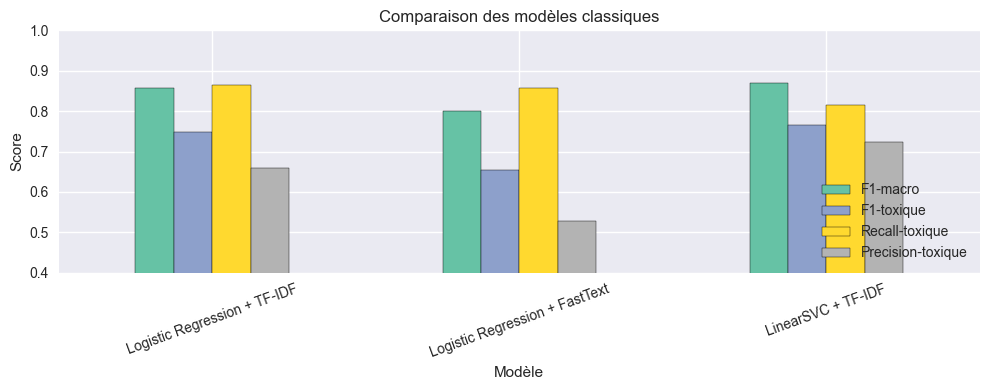

 Figure sauvegardée → figures/models_comparison.png


In [6]:
results = pd.DataFrame([metrics_lr_tfidf, metrics_lr_ft, metrics_svm_tfidf])
results = results.set_index('Modèle').round(4)

print('\n TABLEAU COMPARATIF — MODÈLES CLASSIQUES\n')
print(results.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
metrics_to_plot = ['F1-macro', 'F1-toxique', 'Recall-toxique', 'Precision-toxique']
results[metrics_to_plot].plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Comparaison des modèles classiques')
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../figures/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/models_comparison.png')

**Matrice de confusion — meilleur modèle**

La matrice de confusion détaille les erreurs du modèle :
- **Vrais Positifs (TP)** : toxiques bien détectés 
- **Faux Négatifs (FN)** : toxiques manqués  — le pire cas (laisse passer du contenu toxique)
- **Faux Positifs (FP)** : normaux classés toxiques  — censure abusive
- **Vrais Négatifs (TN)** : normaux bien classés 

L'objectif est de **maximiser le Recall** (minimiser les FN).

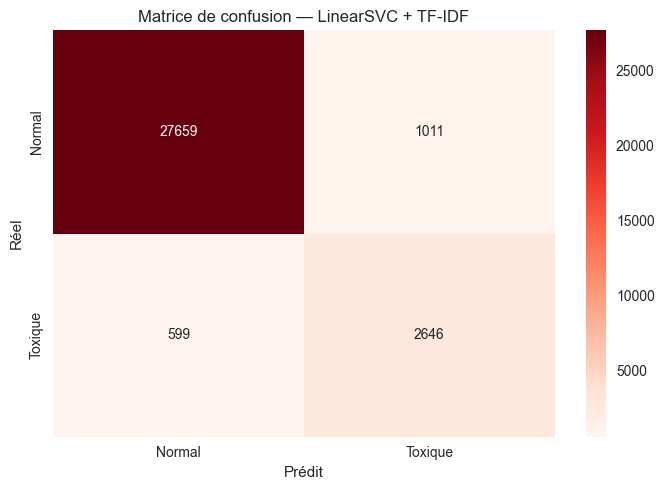

Vrais Négatifs  (TN) : 27,659  → normaux bien classés
Faux Positifs   (FP) : 1,011  → normaux classés toxiques
Faux Négatifs   (FN) : 599  → toxiques manqués 
Vrais Positifs  (TP) : 2,646  → toxiques bien détectés


In [7]:
cm = confusion_matrix(y_test, y_pred_svm_tfidf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Toxique'],
            yticklabels=['Normal', 'Toxique'])
plt.title('Matrice de confusion — LinearSVC + TF-IDF')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais Négatifs  (TN) : {tn:,}  → normaux bien classés')
print(f'Faux Positifs   (FP) : {fp:,}  → normaux classés toxiques')
print(f'Faux Négatifs   (FN) : {fn:,}  → toxiques manqués ')
print(f'Vrais Positifs  (TP) : {tp:,}  → toxiques bien détectés')

**Mots les plus discriminants**

Un avantage de la Logistic Regression + TF-IDF : on peut inspecter
les **coefficients** pour voir quels mots poussent vers "toxique" ou "normal".

C'est impossible avec BERT (boîte noire) — c'est un argument fort
pour conserver les modèles classiques dans le comparatif.
Cette **interprétabilité** est très appréciée dans les applications réelles.

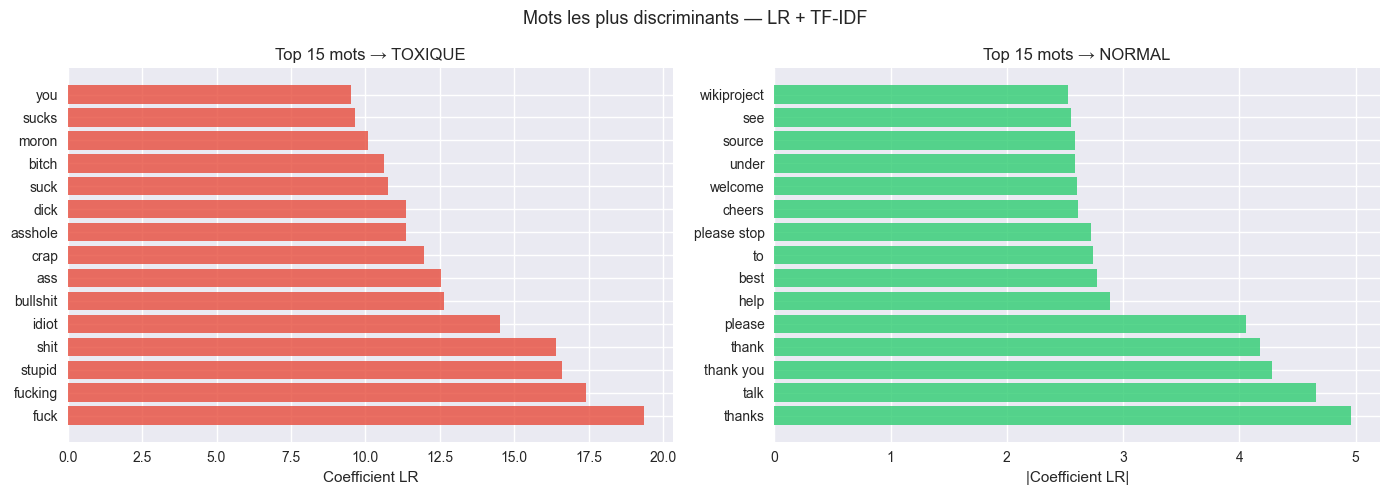

 Figure sauvegardée → figures/discriminant_words.png


In [8]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients  = lr_tfidf.coef_[0]

top_toxic_idx  = coefficients.argsort()[-15:][::-1]
top_normal_idx = coefficients.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(15), coefficients[top_toxic_idx], color='#e74c3c', alpha=0.8)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feature_names[top_toxic_idx])
axes[0].set_title('Top 15 mots → TOXIQUE')
axes[0].set_xlabel('Coefficient LR')

axes[1].barh(range(15), np.abs(coefficients[top_normal_idx]), color='#2ecc71', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feature_names[top_normal_idx])
axes[1].set_title('Top 15 mots → NORMAL')
axes[1].set_xlabel('|Coefficient LR|')

plt.suptitle('Mots les plus discriminants — LR + TF-IDF', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/discriminant_words.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/discriminant_words.png')

### Partie G — Visualisations

**Pourquoi les WordClouds ?**
Les nuages de mots permettent de visualiser rapidement les termes les plus fréquents
dans chaque classe. C'est une façon intuitive de valider que le preprocessing a bien
fonctionné et que les mots discriminants ressortent clairement.

On s'attend à voir dans les commentaires **toxiques** des insultes directes et du
vocabulaire offensant, et dans les commentaires **normaux** des termes neutres liés
aux discussions Wikipedia.

**Observation clé :** Si les mêmes mots apparaissent dans les deux WordClouds,
cela signifie qu'ils ne sont pas discriminants pour notre modèle.

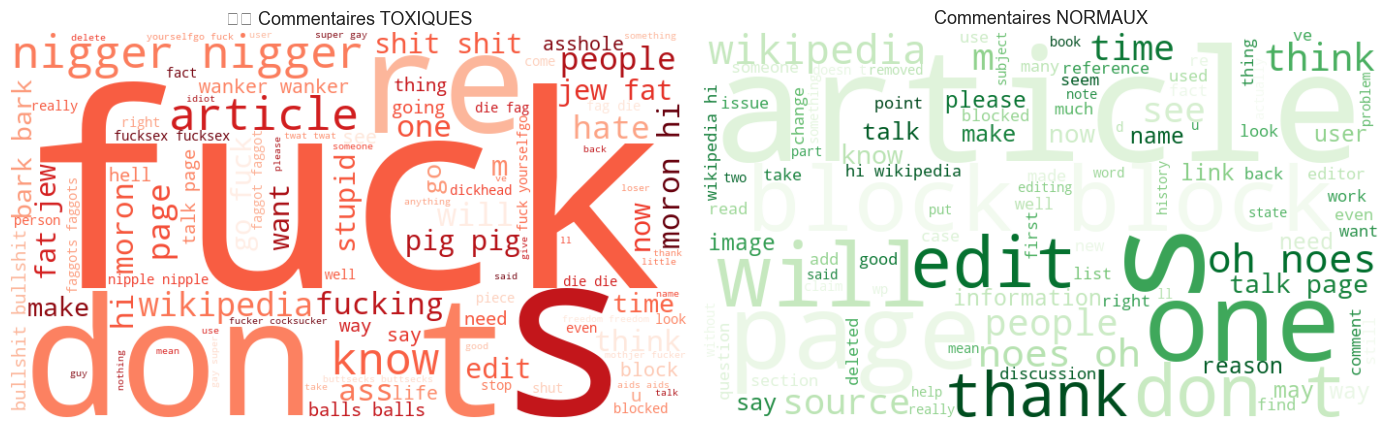

 Figure sauvegardée → figures/wordcloud.png


In [9]:
# pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Commentaires toxiques
toxic_text = ' '.join(df[df['is_toxic']==1]['text_clean'].dropna())
wc_toxic = WordCloud(width=700, height=400, background_color='white',
                     colormap='Reds', max_words=100).generate(toxic_text)
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☠️ Commentaires TOXIQUES', fontsize=13)

# Commentaires normaux
normal_text = ' '.join(df[df['is_toxic']==0]['text_clean'].dropna().sample(5000, random_state=42))
wc_normal = WordCloud(width=700, height=400, background_color='white',
                      colormap='Greens', max_words=100).generate(normal_text)
axes[1].imshow(wc_normal, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires NORMAUX', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/wordcloud.png')

**Projection t-SNE des embeddings FastText**

**Qu'est-ce que t-SNE ?**
t-SNE (t-distributed Stochastic Neighbor Embedding) est une technique de réduction
de dimensionnalité qui projette des vecteurs de haute dimension (ici 300D FastText)
dans un espace 2D visualisable.

**Pourquoi c'est utile ici ?**
Si les commentaires toxiques et normaux forment des **groupes séparés** dans l'espace
2D, cela confirme que les embeddings FastText capturent bien les différences entre
les deux classes — et explique pourquoi un classifieur linéaire comme LR peut les séparer.

Si les groupes se **mélangent**, cela illustre visuellement les cas difficiles
(sarcasme, insultes implicites) que le modèle a du mal à classifier.



Calcul t-SNE... (2-3 min)


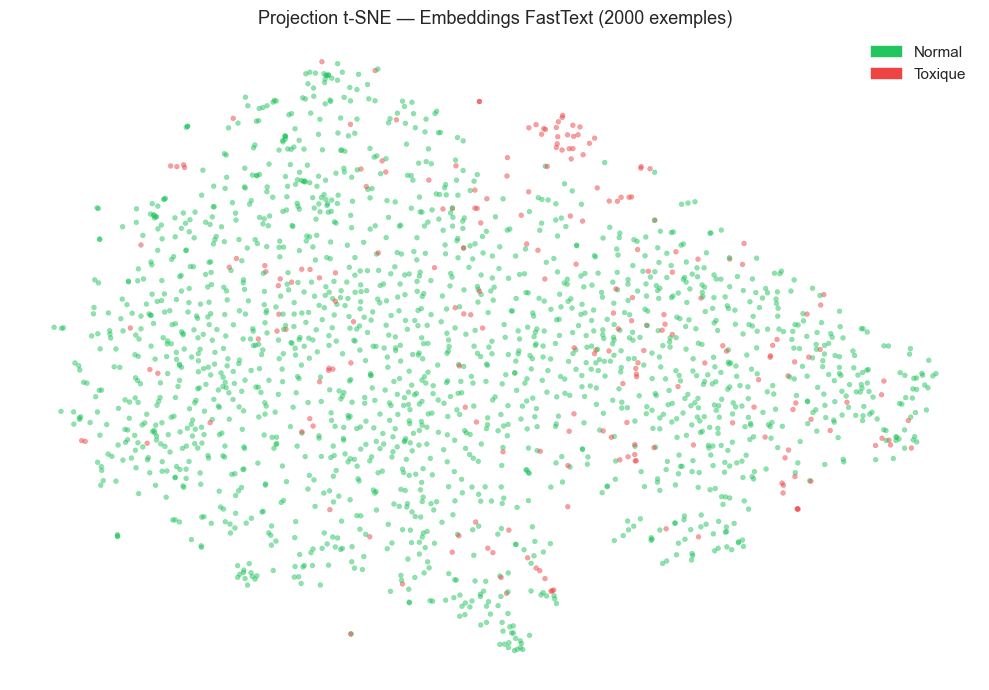

 Figure sauvegardée → figures/tsne_fasttext.png


In [11]:
from sklearn.manifold import TSNE
import numpy as np

print("Calcul t-SNE... (2-3 min)")

# Échantillon 2000 points pour la vitesse
idx = np.random.choice(len(X_train_ft), 2000, replace=False)
X_sample = X_train_ft[idx]
y_sample = y_train.values[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
colors = ['#22c55e' if y == 0 else '#ef4444' for y in y_sample]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.5, s=12)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#22c55e', label='Normal'),
    Patch(color='#ef4444', label='Toxique')
], fontsize=11)
plt.title('Projection t-SNE — Embeddings FastText (2000 exemples)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('../figures/tsne_fasttext.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/tsne_fasttext.png')

### Sauvegarde des résultats

On sauvegarde les métriques et prédictions pour le notebook 04
qui en aura besoin pour le tableau comparatif final avec BERT.

In [12]:
joblib.dump({
    'metrics_lr_tfidf'  : metrics_lr_tfidf,
    'metrics_lr_ft'     : metrics_lr_ft,
    'metrics_svm_tfidf' : metrics_svm_tfidf,
}, '../data/checkpoints/metrics_classiques.joblib')

joblib.dump({
    'y_pred_lr_tfidf'  : y_pred_lr_tfidf,
    'y_pred_lr_ft'     : y_pred_lr_ft,
    'y_pred_svm_tfidf' : y_pred_svm_tfidf,
}, '../data/checkpoints/predictions.joblib')

print(' Checkpoints sauvegardés :')
print('   → data/checkpoints/metrics_classiques.joblib')
print('   → data/checkpoints/predictions.joblib')

 Checkpoints sauvegardés :
   → data/checkpoints/metrics_classiques.joblib
   → data/checkpoints/predictions.joblib


###  Bilan Notebook 03

| Modèle | Accuracy | F1-macro | F1-toxique | Recall-toxique | Precision-toxique |
|--------|----------|----------|------------|----------------|-------------------|
| LR + TF-IDF | 0.9406 | 0.8568 | 0.7474 | 0.8647 | 0.6581 |
| LR + FastText | 0.9078 | 0.8004 | 0.6540 | 0.8573 | 0.5286 |
| LinearSVC + TF-IDF | **0.9496** | **0.8692** | **0.7667** | 0.8154 | **0.7235** |

**Observations :**
- LinearSVC + TF-IDF est le meilleur modèle classique sur toutes les métriques
- TF-IDF surpasse FastText malgré sa simplicité (-0.056 F1-macro pour FastText)
- Le déséquilibre 90/10 est bien géré grâce à `class_weight='balanced'`
- Recall élevé (~86%) → peu de commentaires toxiques manqués 

**Prochain notebook :** `04_bert_analyse.ipynb` — DistilBERT fine-tuning + comparaison finale.